# Bills of Mortality - External Dataset Comparison

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from collections import defaultdict
import re

# Configure plotting
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (15, 8)
warnings.filterwarnings('ignore')

We begin by loading both datasets.

In [4]:
# Load our dataset
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/all_bills.csv
our_bills = pd.read_csv('all_bills.csv')
our_bills.head()

--2025-11-05 15:22:44--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/all_bills.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 133598751 (127M) [text/plain]
Saving to: ‘all_bills.csv.2’

all_bills.csv.2     100%[===================>] 127.41M   103MB/s    in 1.2s    

2025-11-05 15:22:45 (103 MB/s) - ‘all_bills.csv.2’ saved [133598751/133598751]



,parish_id,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier
0,24,buried,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto
1,24,plague,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto
2,1,buried,1,1662,1662121616621223,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto
3,1,plague,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto
4,2,buried,1,1662,1662121616621223,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto


In [85]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/causes_of_death.csv
our_cod = pd.read_csv('causes_of_death.csv')
our_cod.head()

--2025-11-05 17:33:15--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/causes_of_death.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 40909546 (39M) [text/plain]
Saving to: ‘causes_of_death.csv’

causes_of_death.csv 100%[===================>]  39.01M  2.40MB/s    in 15s     

2025-11-05 17:33:31 (2.54 MB/s) - ‘causes_of_death.csv’ saved [40909546/40909546]



,death,count,year,joinid,descriptive_text,source_name,definition,definition_source,bill_type
0,cause,NaN,1657,1657010116570107,NaN,2025-10-20-millar-generalbills-preplague-cause...,NaN,NaN,general
1,number,463.0,1657,1657010116570107,NaN,2025-10-20-millar-generalbills-preplague-cause...,NaN,NaN,general
2,cause 1,NaN,1657,1657010116570107,NaN,2025-10-20-millar-generalbills-preplague-cause...,NaN,NaN,general
3,number 1,869.0,1657,1657010116570107,NaN,2025-10-20-millar-generalbills-preplague-cause...,NaN,NaN,general
4,cause 2,NaN,1657,1657010116570107,NaN,2025-10-20-millar-generalbills-preplague-cause...,NaN,NaN,general


In [138]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/weeks.csv
our_weeks = pd.read_csv('weeks.csv')

# Before merging, drop the existing 'year' columns from our_cod and our_bills
# These seem to be named year_x from previous merges
if 'year_x' in our_cod.columns:
    our_cod = our_cod.drop(columns=['year_x'])
if 'year_x' in our_bills.columns:
    our_bills = our_bills.drop(columns=['year_x'])

--2025-11-05 17:51:40--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/weeks.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 512916 (501K) [text/plain]
Saving to: ‘weeks.csv.5’

weeks.csv.5         100%[===================>] 500.89K  --.-KB/s    in 0.03s   

2025-11-05 17:51:40 (18.3 MB/s) - ‘weeks.csv.5’ saved [512916/512916]



In [ ]:
# Join our weeks to causes of death by joinid
# The 'year' and other week-related columns from our_weeks will be added
our_cod = our_cod.merge(our_weeks, on='joinid', how='left')

# Join our weeks to parishes by joinid
# The 'year' and other week-related columns from our_weeks will be added
our_bills = our_bills.merge(our_weeks, on='joinid', how='left')

In [5]:
# Load external dataset
!wget https://raw.githubusercontent.com/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data-compare/WeekDict.txt
!wget https://raw.githubusercontent.com/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data-compare/counts.txt
!wget https://raw.githubusercontent.com/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data-compare/ParcodeDict.txt
!wget https://raw.githubusercontent.com/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data-compare/cods.txt

--2025-11-05 15:27:35--  https://raw.githubusercontent.com/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data-compare/WeekDict.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 611849 (598K) [text/plain]
Saving to: ‘WeekDict.txt’

WeekDict.txt        100%[===================>] 597.51K  --.-KB/s    in 0.03s   

2025-11-05 15:27:35 (21.7 MB/s) - ‘WeekDict.txt’ saved [611849/611849]

--2025-11-05 15:27:35--  https://raw.githubusercontent.com/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data-compare/counts.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request

In [139]:
ext_weeks = pd.read_csv('WeekDict.txt', sep='|')
ext_counts = pd.read_csv('counts.txt', sep='|')
ext_parishes = pd.read_csv('ParcodeDict.txt', sep='|')
ext_cods = pd.read_csv('cods.txt', sep='|')

In [140]:
our_years = set(our_bills['year'].unique())
ext_years = set(ext_weeks['year'].unique())
overlap_years = our_years.intersection(ext_years)
print(f"Years in both datasets: {len(overlap_years)} ({min(overlap_years)}-{max(overlap_years)})")

Years in both datasets: 106 (1644-1752)


## Transform External Data for Comparison

Convert external dataset structure to match our format for direct comparison. We use our crosswalk of parish names to ensure that parish names are consistent across the two datasets.

In [141]:
def transform_external_data():
    """Transform external dataset to match our structure, using crosswalk for parish names."""
    # 1. Parse weekID to extract year and week
    ext_counts_transformed = ext_counts.copy()
    ext_counts_transformed[['year', 'week']] = ext_counts_transformed['weekID'].str.split('/', expand=True)
    ext_counts_transformed['year'] = ext_counts_transformed['year'].astype(int)
    ext_counts_transformed['week'] = ext_counts_transformed['week'].astype(int)

    # 2. Add parish information
    ext_counts_transformed = ext_counts_transformed.merge(
        ext_parishes[['parcode', 'parish', 'billsgroupafter1660']],
        on='parcode',
        how='left'
    )

    # 3. Create a unique parish_id (use parcode mapping)
    parish_mapping = {parcode: idx+1 for idx, parcode in enumerate(ext_parishes['parcode'].unique())}
    ext_counts_transformed['parish_id'] = ext_counts_transformed['parcode'].map(parish_mapping)

    # 4. Map count types to our format
    count_type_mapping = {
        'buried': 'buried',
        'plague': 'plague',
        'christened': 'christened'
    }
    ext_counts_transformed['count_type'] = ext_counts_transformed['counttype'].map(count_type_mapping)

    # 5. Rename columns to match our structure
    ext_counts_transformed = ext_counts_transformed.rename(columns={
        'countn': 'count',
        'weekID': 'external_week_id',
        'parcode': 'external_parish_code'
    })

    # 6. Add source identifier
    ext_counts_transformed['source'] = 'external_wellcome_campop'

    # 7. Add missing/illegible flags (assume all external data is clean)
    ext_counts_transformed['missing'] = False
    ext_counts_transformed['illegible'] = False

    # 8. Create joinid equivalent (simplified)
    ext_counts_transformed['joinid'] = ext_counts_transformed['year'].astype(str) + '_w' + ext_counts_transformed['week'].astype(str)

    print(f"Transformed {len(ext_counts_transformed):,} external records")

    return ext_counts_transformed, parish_mapping

ext_transformed, ext_parish_mapping = transform_external_data()

# Show sample of transformed data
print("\nSample of transformed external data:")
sample_cols = ['parish_id', 'year', 'week', 'count_type', 'count', 'parish']
ext_transformed[sample_cols].head(10)


Transformed 552,440 external records

Sample of transformed external data:


,parish_id,year,week,count_type,count,parish
0,53,1644,15,plague,1,St George Southwark
1,136,1644,15,plague,1,St Olave Southwark
2,161,1644,15,plague,3,St Mary Whitechappel
3,147,1644,15,plague,1,St Mary Rothorithe
4,153,1644,15,plague,2,St Dunstan Stepney
5,9,1644,16,buried,1,St Alban Woodstreet
6,3,1644,16,buried,2,Allhallows Great
7,6,1644,16,buried,1,Allhallows Lesse
8,8,1644,16,buried,1,Allhallows Staining
9,20,1644,16,buried,1,St Andrew Undershaft


In [5]:
# TODO: Side by side comparison of parish counts for our data and theirs


## Coverage Gap Analysis

We look to see what kinds of temporal and spatial gaps exist between the two datasets per year. We examine how many records exist for our dataset (`our_records`) and how many recoreds exist in the external dataset (`ext_records`). We then also compare how many parishes we have and how many the external dataset has.

In [142]:
def analyze_coverage_gaps():
    """Analyze temporal and spatial coverage gaps between datasets."""
    # Focus on overlap period for detailed analysis
    our_overlap = our_bills[our_bills['year'].isin(overlap_years)]
    ext_overlap = ext_transformed[ext_transformed['year'].isin(overlap_years)]

    print(f"\n=== OVERLAP PERIOD DETAILS ({min(overlap_years)}-{max(overlap_years)}) ===")
    print(f"Our total records: {len(our_overlap):,}")
    print(f"External total records: {len(ext_overlap):,}")

    # Year-by-year comparison in overlap period
    yearly_comparison = []
    for year in sorted(overlap_years):
        our_year_data = our_overlap[our_overlap['year'] == year]
        ext_year_data = ext_overlap[ext_overlap['year'] == year]

        yearly_comparison.append({
            'year': year,
            'our_records': len(our_year_data),
            'ext_records': len(ext_year_data),
            'our_parishes': our_year_data['parish_id'].nunique(),
            'ext_parishes': ext_year_data['parish_id'].nunique(),
            'our_weeks': our_year_data['joinid'].nunique() if 'joinid' in our_year_data.columns else 0,
            'ext_weeks': ext_year_data['week'].nunique()
        })

    yearly_df = pd.DataFrame(yearly_comparison)

    print(f"\nTop 10 years by total coverage:")
    yearly_df['total_records'] = yearly_df['our_records'] + yearly_df['ext_records']
    top_years = yearly_df.nlargest(10, 'total_records')
    print(top_years[['year', 'our_records', 'ext_records', 'our_parishes', 'ext_parishes']].to_string(index=False))

    return yearly_df, our_overlap, ext_overlap

coverage_analysis, our_overlap_data, ext_overlap_data = analyze_coverage_gaps()


=== OVERLAP PERIOD DETAILS (1644-1752) ===
Our total records: 1,059,961
External total records: 341,423

Top 10 years by total coverage:
 year  our_records  ext_records  our_parishes  ext_parishes
 1676        24392         3538           134           131
 1665        19938         6965           137           132
 1669        24186         2353           134           110
 1675        17960         3378           134           129
 1666        16936         3660           137           132
 1663        17806         2247           137           130
 1677        15816         3479           134           130
 1674        15280         3478           134           130
 1691        14541         3666           137           129
 1690        14463         3637           137           130


## Plague and Burial Count Comparison

Direct comparison of plague and burial counts for matching time periods and parishes.

In [143]:
"""Compare plague and burial counts between datasets."""
# Filter for plague and burial data only
our_plague_burial = our_overlap_data[our_overlap_data['count_type'].isin(['plague', 'buried'])]
ext_plague_burial = ext_overlap_data[ext_overlap_data['count_type'].isin(['plague', 'buried'])]

print(f"Our plague/burial records: {len(our_plague_burial):,}")
print(f"External plague/burial records: {len(ext_plague_burial):,}")

# Aggregate by year and count type for comparison
our_yearly = our_plague_burial.groupby(['year', 'count_type'])['count'].sum().reset_index()
our_yearly['dataset'] = 'ours'

ext_yearly = ext_plague_burial.groupby(['year', 'count_type'])['count'].sum().reset_index()
ext_yearly['dataset'] = 'external'


Our plague/burial records: 1,059,961
External plague/burial records: 339,619


In [144]:
our_yearly.head()

,year,count_type,count,dataset
0,1644,buried,8205,ours
1,1644,plague,1248,ours
2,1646,buried,11462,ours
3,1646,plague,1856,ours
4,1647,buried,12477,ours


In [145]:
ext_yearly.head()

,year,count_type,count,dataset
0,1644,buried,1285,external
1,1644,plague,108,external
2,1646,buried,10370,external
3,1646,plague,1989,external
4,1647,buried,14588,external


In [146]:
# Combine for comparison
combined_yearly = pd.concat([our_yearly, ext_yearly], ignore_index=True)
combined_yearly.sort_values(['year', 'dataset']).head()

,year,count_type,count,dataset
160,1644,buried,1285,external
161,1644,plague,108,external
0,1644,buried,8205,ours
1,1644,plague,1248,ours
162,1646,buried,10370,external


In [147]:
# Pivot for side-by-side comparison
comparison_pivot = combined_yearly.pivot_table(
  index=['year', 'count_type'],
  columns='dataset',
  values='count',
  fill_value=0
).reset_index()

comparison_pivot.head(10)

dataset,year,count_type,external,ours
0,1644,buried,1285.0,8205.0
1,1644,plague,108.0,1248.0
2,1646,buried,10370.0,11462.0
3,1646,plague,1989.0,1856.0
4,1647,buried,14588.0,12477.0
5,1647,plague,3293.0,3115.0
6,1649,buried,4030.0,5746.0
7,1649,plague,24.0,26.0
8,1650,buried,2563.0,128.0
9,1650,plague,0.0,0.0


In [148]:
# Calculate differences
comparison_pivot['difference'] = comparison_pivot['ours'] - comparison_pivot['external']
comparison_pivot['abs_difference'] = abs(comparison_pivot['difference'])
comparison_pivot['percent_difference'] = np.where(
  comparison_pivot['external'] > 0,
  (comparison_pivot['difference'] / comparison_pivot['external']) * 100,
    np.nan
)

In [149]:
print(f"\nTop 10 largest absolute differences:")
top_differences = comparison_pivot.nlargest(10, 'abs_difference')
display_cols = ['year', 'count_type', 'ours', 'external', 'difference', 'percent_difference']
top_differences.head(10)[display_cols]


Top 10 largest absolute differences:


dataset,year,count_type,ours,external,difference,percent_difference
134,1727,buried,52219.0,28407.0,23812.0,83.824409
130,1723,buried,50580.0,29197.0,21383.0,73.236976
133,1726,buried,49795.0,29640.0,20155.0,67.999325
135,1728,buried,47595.0,27810.0,19785.0,71.143474
121,1714,buried,45688.0,26566.0,19122.0,71.979222
136,1729,buried,48361.0,29674.0,18687.0,62.974321
132,1725,buried,44111.0,25511.0,18600.0,72.909725
129,1722,buried,44096.0,25748.0,18348.0,71.259904
131,1724,buried,44281.0,25957.0,18324.0,70.593674
127,1720,buried,43512.0,25450.0,18062.0,70.970530


In [150]:
# Buried
buried_data_compare = comparison_pivot[comparison_pivot['count_type'] == 'buried']
major_buried_years = buried_data_compare.nlargest(10, 'external')


print(f"\nTop buried differences:")
major_buried_years.head(10)


Top buried differences:


dataset,year,count_type,external,ours,difference,abs_difference,percent_difference
36,1665,buried,97305.0,81542.0,-15763.0,15763.0,-16.199579
148,1741,buried,32156.0,33329.0,1173.0,1173.0,3.647842
147,1740,buried,30818.0,42132.0,11314.0,11314.0,36.712311
136,1729,buried,29674.0,48361.0,18687.0,18687.0,62.974321
133,1726,buried,29640.0,49795.0,20155.0,20155.0,67.999325
140,1733,buried,29206.0,39849.0,10643.0,10643.0,36.441142
130,1723,buried,29197.0,50580.0,21383.0,21383.0,73.236976
134,1727,buried,28407.0,52219.0,23812.0,23812.0,83.824409
126,1719,buried,28347.0,45883.0,17536.0,17536.0,61.861925
153,1746,buried,28091.0,27761.0,-330.0,330.0,-1.174753


In [151]:

# Plague
plague_data = comparison_pivot[comparison_pivot['count_type'] == 'plague']
major_plague_years = plague_data.nlargest(10, 'external')

print(f"\nTop plague differences:")
major_plague_years.head(10)


Top plague differences:


dataset,year,count_type,external,ours,difference,abs_difference,percent_difference
37,1665,plague,68756.0,53602.0,-15154.0,15154.0,-22.040258
5,1647,plague,3293.0,3115.0,-178.0,178.0,-5.405405
39,1666,plague,2007.0,2091.0,84.0,84.0,4.185351
3,1646,plague,1989.0,1856.0,-133.0,133.0,-6.686777
1,1644,plague,108.0,1248.0,1140.0,1140.0,1055.555556
41,1667,plague,35.0,18.0,-17.0,17.0,-48.571429
25,1659,plague,27.0,30.0,3.0,3.0,11.111111
7,1649,plague,24.0,26.0,2.0,2.0,8.333333
17,1654,plague,16.0,17.0,1.0,1.0,6.250000
11,1651,plague,15.0,18.0,3.0,3.0,20.000000


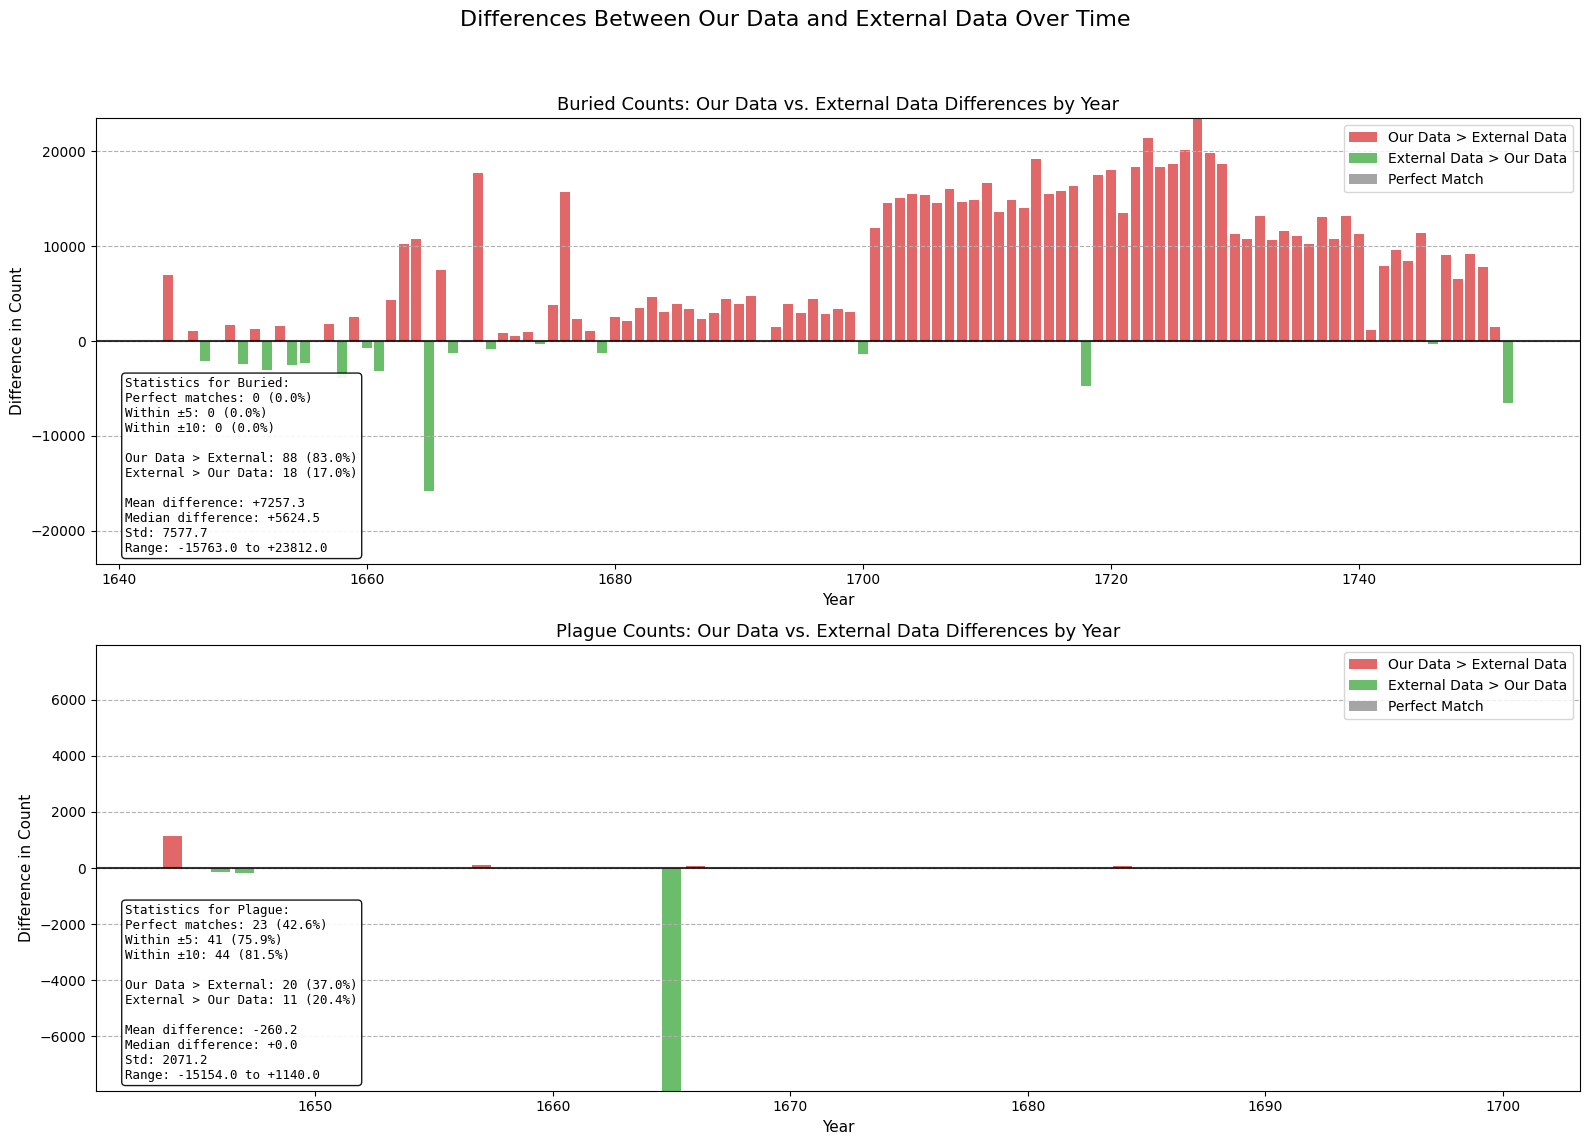

In [152]:
# Visualize the differences for buried and plague counts using the provided example style
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Differences Between Our Data and External Data Over Time', fontsize=16, y=0.98)

count_types = ['buried', 'plague']
# Using distinct colors for positive and negative differences as in the example
pos_color = '#d62728' # Reddish for positive difference (Our Data > External Data)
neg_color = '#2ca02c' # Greenish for negative difference (External Data > Our Data)
zero_color = '#7f7f7f' # Grey for perfect match
titles = ['Buried Counts: Our Data vs. External Data Differences by Year', 'Plague Counts: Our Data vs. External Data Differences by Year']

# Ensure comparison_pivot is available and contains the necessary columns
if 'comparison_pivot' in locals() and not comparison_pivot.empty:
    for idx, count_type in enumerate(count_types):
        ax = ax1 if idx == 0 else ax2

        # Use 'comparison_pivot' dataframe filtered by count_type
        comparison_data = comparison_pivot[comparison_pivot['count_type'] == count_type].copy()

        if len(comparison_data) == 0:
            ax.text(0.5, 0.5, f'No data available for {count_type}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(titles[idx], fontsize=13)
            ax.set_xlabel('Year', fontsize=11)
            ax.set_ylabel('Difference in Count', fontsize=11)
            continue

        # Sort by year for consistent plotting
        comparison_data = comparison_data.sort_values('year').reset_index(drop=True)

        # Color bars based on positive/negative difference
        colors_bars = [
            pos_color if x > 0 else neg_color if x < 0 else zero_color
            for x in comparison_data['difference']
        ]

        bars = ax.bar(comparison_data['year'], comparison_data['difference'], width=0.8, alpha=0.7, color=colors_bars)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8, label='Perfect Match (0)')

        ax.set_xlabel('Year', fontsize=11)
        ax.set_ylabel('Difference in Count', fontsize=11)
        ax.set_title(titles[idx], fontsize=13)

        # Add legend explaining the colors
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=pos_color, alpha=0.7, label='Our Data > External Data'),
            Patch(facecolor=neg_color, alpha=0.7, label='External Data > Our Data'),
            Patch(facecolor=zero_color, alpha=0.7, label='Perfect Match')
        ]
        ax.legend(handles=legend_elements, loc='upper right')
        ax.grid(axis='y', linestyle='--') # Add grid for clarity

        # Add summary statistics
        perfect_matches = (comparison_data['difference'] == 0).sum()
        within_5 = (abs(comparison_data['difference']) <= 5).sum()
        within_10 = (abs(comparison_data['difference']) <= 10).sum()
        positive = (comparison_data['difference'] > 0).sum()
        negative = (comparison_data['difference'] < 0).sum()

        stats_text = f"""Statistics for {count_type.title()}:
Perfect matches: {perfect_matches:,} ({perfect_matches/len(comparison_data)*100:.1f}%)
Within ±5: {within_5:,} ({within_5/len(comparison_data)*100:.1f}%)
Within ±10: {within_10:,} ({within_10/len(comparison_data)*100:.1f}%)

Our Data > External: {positive:,} ({positive/len(comparison_data)*100:.1f}%)
External > Our Data: {negative:,} ({negative/len(comparison_data)*100:.1f}%)

Mean difference: {comparison_data['difference'].mean():+.1f}
Median difference: {comparison_data['difference'].median():+.1f}
Std: {comparison_data['difference'].std():.1f}
Range: {comparison_data['difference'].min():+.1f} to {comparison_data['difference'].max():+.1f}"""

        ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, verticalalignment='bottom',
                fontsize=9, family='monospace', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

        # Set y-axis limits based on quantiles to handle outliers
        if len(comparison_data) > 0:
            q1 = comparison_data['difference'].quantile(0.01)
            q99 = comparison_data['difference'].quantile(0.99)
            y_range = max(abs(q1), abs(q99))
            ax.set_ylim(-y_range * 1.1, y_range * 1.1)


    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    plt.show()
else:
    print("Comparison data (comparison_pivot) not available for plotting.")

In [153]:
def plot_difference_by_year_range(start_year=None, end_year=None):
    """
    Visualizes the differences in buried and plague counts between our data
    and external data for a specified year range, using the provided example style.

    Args:
        start_year (int, optional): The starting year for the plot (inclusive).
                                    Defaults to the minimum year in the data.
        end_year (int, optional): The ending year for the plot (inclusive).
                                  Defaults to the maximum year in the data.
    """
    if 'comparison_pivot' not in globals() or comparison_pivot.empty:
        print("Comparison data (comparison_pivot) not available for plotting.")
        return

    # Filter data based on year range
    filtered_data = comparison_pivot.copy()
    if start_year is not None:
        filtered_data = filtered_data[filtered_data['year'] >= start_year]
    if end_year is not None:
        filtered_data = filtered_data[filtered_data['year'] <= end_year]

    if filtered_data.empty:
        print(f"No data available for the specified year range: {start_year}-{end_year}")
        return

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
    fig.suptitle(f'Differences Between Our Data and External Data ({start_year}-{end_year})', fontsize=16, y=0.98)

    count_types = ['buried', 'plague']
    pos_color = '#d62728'  # Reddish for positive difference (Our Data > External Data)
    neg_color = '#2ca02c'  # Greenish for negative difference (External Data > Our Data)
    zero_color = '#7f7f7f'  # Grey for perfect match
    titles = [
        f'Buried Counts: Our Data vs. External Data Differences ({start_year}-{end_year})',
        f'Plague Counts: Our Data vs. External Data Differences ({start_year}-{end_year})'
    ]

    for idx, count_type in enumerate(count_types):
        ax = ax1 if idx == 0 else ax2

        # Use filtered_data dataframe filtered by count_type
        comparison_data = filtered_data[filtered_data['count_type'] == count_type].copy()

        if len(comparison_data) == 0:
            ax.text(0.5, 0.5, f'No data available for {count_type} in this range', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(titles[idx], fontsize=13)
            ax.set_xlabel('Year', fontsize=11)
            ax.set_ylabel('Difference in Count', fontsize=11)
            continue

        # Sort by year for consistent plotting
        comparison_data = comparison_data.sort_values('year').reset_index(drop=True)

        # Color bars based on positive/negative difference
        colors_bars = [
            pos_color if x > 0 else neg_color if x < 0 else zero_color
            for x in comparison_data['difference']
        ]

        bars = ax.bar(comparison_data['year'], comparison_data['difference'], width=0.8, alpha=0.7, color=colors_bars)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8, label='Perfect Match (0)')

        ax.set_xlabel('Year', fontsize=11)
        ax.set_ylabel('Difference in Count', fontsize=11)
        ax.set_title(titles[idx], fontsize=13)

        # Add legend explaining the colors
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=pos_color, alpha=0.7, label='Our Data > External Data'),
            Patch(facecolor=neg_color, alpha=0.7, label='External Data > Our Data'),
            Patch(facecolor=zero_color, alpha=0.7, label='Perfect Match')
        ]
        ax.legend(handles=legend_elements, loc='upper right')
        ax.grid(axis='y', linestyle='--')  # Add grid for clarity

        # Add summary statistics
        perfect_matches = (comparison_data['difference'] == 0).sum()
        within_5 = (abs(comparison_data['difference']) <= 5).sum()
        within_10 = (abs(comparison_data['difference']) <= 10).sum()
        positive = (comparison_data['difference'] > 0).sum()
        negative = (comparison_data['difference'] < 0).sum()

        stats_text = f"""Statistics for {count_type.title()}:
Perfect matches: {perfect_matches:,} ({perfect_matches/len(comparison_data)*100:.1f}%)
Within ±5: {within_5:,} ({within_5/len(comparison_data)*100:.1f}%)
Within ±10: {within_10:,} ({within_10/len(comparison_data)*100:.1f}%)

Our Data > External: {positive:,} ({positive/len(comparison_data)*100:.1f}%)
External > Our Data: {negative:,} ({negative/len(comparison_data)*100:.1f}%)

Mean difference: {comparison_data['difference'].mean():+.1f}
Median difference: {comparison_data['difference'].median():+.1f}
Std: {comparison_data['difference'].std():.1f}
Range: {comparison_data['difference'].min():+.1f} to {comparison_data['difference'].max():+.1f}"""

        ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, verticalalignment='bottom',
                fontsize=9, family='monospace', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

        # Set y-axis limits based on quantiles to handle outliers
        if len(comparison_data) > 0:
            q1 = comparison_data['difference'].quantile(0.01)
            q99 = comparison_data['difference'].quantile(0.99)
            y_range = max(abs(q1), abs(q99))
            ax.set_ylim(-y_range * 1.1, y_range * 1.1)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

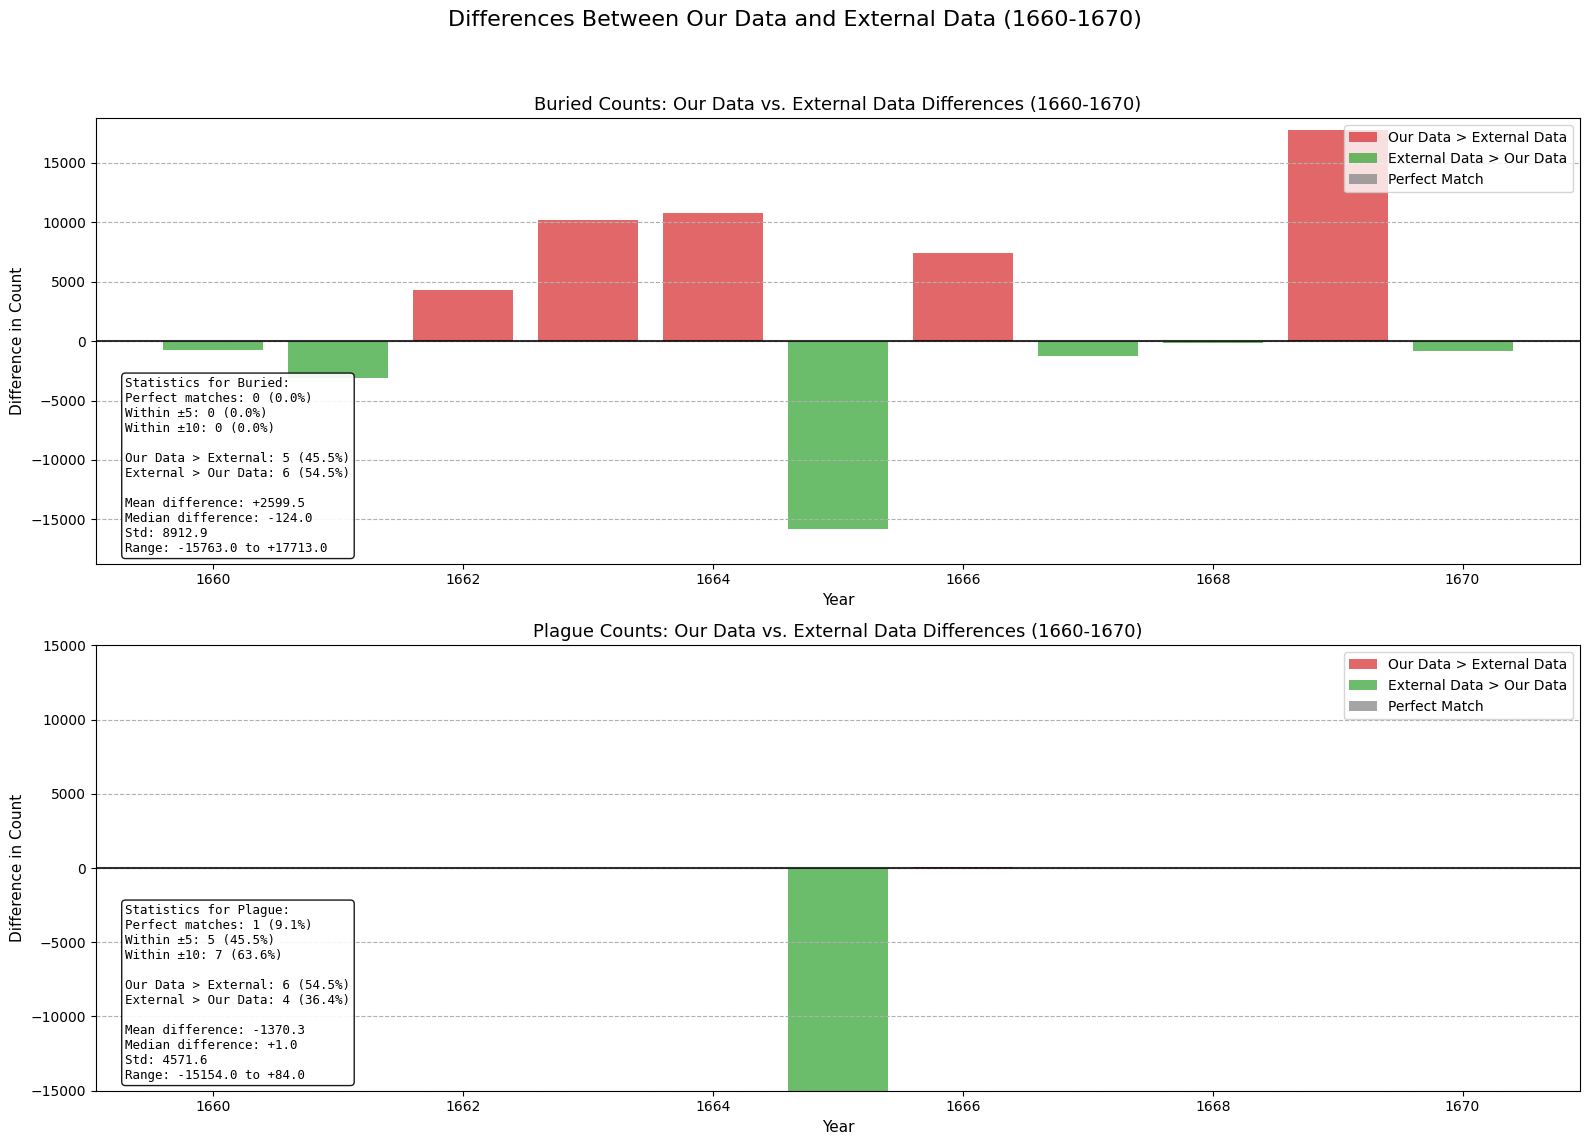

In [154]:
plot_difference_by_year_range(1660, 1670) # adjust years and re-run this cell

## Cause of Death Data Comparison

Compare our cause of death data with their standardized COD data.

In [155]:
# Compare the causes of death between the datasets.

# We first transform the external data to allow for comparison against ours
ext_cod_transformed = ext_cods.copy()
ext_cod_transformed[['year', 'week']] = ext_cod_transformed['weekID'].str.split('/', expand=True)
ext_cod_transformed['year'] = ext_cod_transformed['year'].astype(int)
ext_cod_transformed['week'] = ext_cod_transformed['week'].astype(int)

# Filter for overlap years
overlap_years = set(our_overlap_data['year'].unique())
ext_cod_overlap = ext_cod_transformed[ext_cod_transformed['year'].isin(overlap_years)]

In [156]:
print(f"\nExternal cause of death records in overlap years: {len(ext_cod_overlap):,}")
print(f"External unique causes: {ext_cod_overlap['codspellcorrex'].nunique()}")


External cause of death records in overlap years: 185,834
External unique causes: 249


In [157]:
# Now we look at the top causes in our dataset (our_cod)
# Correcting column names based on our_cod structure ('death' and 'count')
our_cod_counts = our_cod.groupby('death')['count'].sum().nlargest(20)

# Print top causes from our dataset
print("Top 20 causes of death (our dataset):")
our_cod_counts.head(20)

Top 20 causes of death (our dataset):


,count
death,
convulsion,160195.0
consumption,129173.0
fever,109384.0
plague,91701.0
number 43,70982.0
aged,59767.0
flox and small pox,52334.0
teeth,49674.0
number 2,48386.0


In [158]:
# Top causes of death in external data
top_causes_ext = ext_cod_overlap.groupby('codspellcorrex')['codn'].sum().nlargest(20)
print(f"\nTop 20 causes of death (external dataset):")
top_causes_ext.head(20)


Top 20 causes of death (external dataset):


,codn
codspellcorrex,
Convulsions,479123
Consumption,327941
Fever,298372
Aged,153177
Teeth,122509
Griping in the Guts,109087
Smallpox,99505
Dropsy,84164
Plague,75620


In [159]:
# Plague-specific comparison
ext_plague_cod = ext_cod_overlap[ext_cod_overlap['codspellcorrex'].str.contains('Plague', case=False, na=False)]
print(f"\nPlague deaths by year (external COD data):")
ext_plague_cod.sort_values(['year', 'week']).head(10)


Plague deaths by year (external COD data):


,codID,weekID,cod,codspellcorrex,codn,year,week
15,4370,1644/15,Plague,Plague,5,1644,15
37,4677,1644/16,Plague,Plague,8,1644,16
66,4984,1644/17,Plague,Plague,17,1644,17
95,5291,1644/18,Plague,Plague,17,1644,18
121,5598,1644/19,Plague,Plague,17,1644,19
149,5905,1644/20,Plague,Plague,17,1644,20
239,36914,1646/15,Plague,Plague,2,1646,15
274,37221,1646/16,Plague,Plague,4,1646,16
305,37528,1646/17,Plague,Plague,8,1646,17
339,37835,1646/18,Plague,Plague,6,1646,18


In [160]:
# Compare with our plague data
our_plague = our_overlap_data[our_overlap_data['count_type'] == 'plague']

print(f"\nPlague comparison:")
our_plague.sort_values(['year', 'week_number']).head(10)


Plague comparison:


KeyError: 'week_number'

## 6. Parish Coverage Analysis

Compare which parishes are covered in each dataset.

In [2]:
def analyze_parish_coverage():
    """Analyze parish coverage differences between datasets, showing parish names."""

    print("=== PARISH COVERAGE ANALYSIS ===")

    # Get unique parishes from our data (using our_overlap_data for consistency with previous analysis)
    our_parishes = set(our_overlap_data['parish_id'].unique())
    print(f"Unique parishes in our dataset (overlap period): {len(our_parishes)}")

    # Get unique parishes from external data (using ext_overlap_data)
    ext_parishes_ids = set(ext_overlap_data['parish_id'].unique())
    print(f"Unique parishes in external dataset (overlap period): {len(ext_parishes_ids)}")

    # Find overlap and unique parishes
    parishes_in_both = our_parishes.intersection(ext_parishes_ids)
    parishes_only_in_ours = our_parishes - ext_parishes_ids
    parishes_only_in_external = ext_parishes_ids - our_parishes

    print(f"\nParish Overlap:")
    print(f"Parishes found in both datasets: {len(parishes_in_both)}")
    print(f"Parishes only in our dataset: {len(parishes_only_in_ours)}")
    print(f"Parishes only in external dataset: {len(parishes_only_in_external)}")

    # Prepare parish_id to name lookup for external data
    ext_id_to_name = {}
    for code, pid in ext_parish_mapping.items():
        # Ensure the parcode exists in ext_parishes before accessing .iloc[0]
        if code in ext_parishes['parcode'].values:
            name = ext_parishes[ext_parishes['parcode'] == code]['parish'].iloc[0]
            ext_id_to_name[pid] = name
        else:
            print(f"Warning: Parcode {code} not found in external parishes dictionary.")


    print("\nSample of parishes only in our dataset (IDs):")
    # Print a sample of IDs for parishes only in our data
    sample_size = min(10, len(parishes_only_in_ours))
    for i, parish_id in enumerate(list(parishes_only_in_ours)[:sample_size]):
        print(f"  ID: {parish_id}")

    print("\nSample of parishes only in external dataset (Names):")
    # Print names for parishes only in external data
    sample_size = min(10, len(parishes_only_in_external))
    for i, parish_id in enumerate(list(parishes_only_in_external)[:sample_size]):
        parish_name = ext_id_to_name.get(parish_id, f"Unknown Parish ({parish_id})")
        print(f"  {parish_name}")

    print("\nSample of parishes found in both datasets (Names from External Mapping):")
    # Print names for parishes in both data
    sample_size = min(10, len(parishes_in_both))
    for i, parish_id in enumerate(list(parishes_in_both)[:sample_size]):
        parish_name = ext_id_to_name.get(parish_id, f"Unknown Parish ({parish_id})")
        print(f"  {parish_name}")

    # Our parish coverage activity counts
    our_parishes_active = our_overlap_data['parish_id'].value_counts()

    # External parish coverage activity counts
    ext_parishes_active = ext_overlap_data['parish_id'].value_counts()

    # Show most active parishes in each dataset
    print(f"\nTop 15 most active parishes (by record count):")
    print("\nOur dataset:")
    for parish_id, count in our_parishes_active.head(15).items():
        # Try to get parish name from external mapping if possible
        parish_name = ext_id_to_name.get(parish_id, f"Parish {parish_id}")
        print(f"  {parish_name}: {count:,} records")

    print(f"\nExternal dataset:")
    for parish_id, count in ext_parishes_active.head(15).items():
        parish_name = ext_id_to_name.get(parish_id, f"Parish {parish_id}")
        print(f"  {parish_name}: {count:,} records")

    # Geographic distribution (using external parish groups) - Keep this part as it was
    ext_with_groups = ext_overlap_data.merge(
        ext_parishes[['parcode', 'billsgroupafter1660']],
        left_on='external_parish_code', # Assuming external_parish_code exists in ext_overlap_data
        right_on='parcode',
        how='left'
    )
    if 'billsgroupafter1660' in ext_with_groups.columns:
         print(f"\nExternal data geographic distribution:")
         display(ext_with_groups['billsgroupafter1660'].value_counts())
    else:
        print("\nCould not perform external data geographic distribution analysis.")


    return our_parishes_active, ext_parishes_active

parish_analysis = analyze_parish_coverage()

=== PARISH COVERAGE ANALYSIS ===


NameError: name 'our_overlap_data' is not defined

## Consistency Analysis

Detailed analysis of data consistency where both datasets overlap.

In [172]:
def perform_consistency_analysis():
    """Perform detailed consistency analysis for overlapping data."""

    print("=== DATA CONSISTENCY ANALYSIS ===")

    # Focus on years where both datasets have substantial data
    substantial_years = coverage_analysis[
        (coverage_analysis['our_records'] >= 100) &
        (coverage_analysis['ext_records'] >= 100)
    ]['year'].tolist()

    print(f"Years with substantial data in both datasets: {len(substantial_years)}")
    if substantial_years:
        print(f"Range: {min(substantial_years)}-{max(substantial_years)}")

    # Statistical comparison for these years
    if substantial_years and plague_burial_comparison is not None:
        substantial_comparison = plague_burial_comparison[
            plague_burial_comparison['year'].isin(substantial_years)
        ]

        print(f"\nStatistical Consistency Metrics:")

        for count_type in ['plague', 'buried']:
            type_data = substantial_comparison[substantial_comparison['count_type'] == count_type]

            if len(type_data) > 0 and 'ours' in type_data.columns and 'external' in type_data.columns:
                # Calculate correlation
                valid_data = type_data[(type_data['ours'] > 0) | (type_data['external'] > 0)]

                if len(valid_data) > 1:
                    correlation = valid_data['ours'].corr(valid_data['external'])

                    # Calculate mean absolute percentage error
                    valid_nonzero = valid_data[valid_data['external'] > 0]
                    if len(valid_nonzero) > 0:
                        mape = np.mean(np.abs((valid_nonzero['ours'] - valid_nonzero['external']) / valid_nonzero['external'])) * 100

                        print(f"\n{count_type.title()} counts:")

                        # Show best and worst matches
                        valid_nonzero['abs_pct_error'] = np.abs((valid_nonzero['ours'] - valid_nonzero['external']) / valid_nonzero['external']) * 100

                        best_matches = valid_nonzero.nsmallest(3, 'abs_pct_error')
                        worst_matches = valid_nonzero.nlargest(3, 'abs_pct_error')

                        print(f"\n  Best matches (lowest % error):")
                        for _, row in best_matches.iterrows():
                            print(f"    {row['year']}: Ours={row['ours']:.0f}, External={row['external']:.0f}, Error={row['abs_pct_error']:.1f}%")

                        print(f"\n  Worst matches (highest % error):")
                        for _, row in worst_matches.iterrows():
                            print(f"    {row['year']}: Ours={row['ours']:.0f}, External={row['external']:.0f}, Error={row['abs_pct_error']:.1f}%")

    # Identify potential data gaps
    print(f"\n=== DATA GAPS ===")

    # Years where one dataset has significantly more data
    coverage_analysis['ratio'] = np.where(
        coverage_analysis['ext_records'] > 0,
        coverage_analysis['our_records'] / coverage_analysis['ext_records'],
        np.inf
    )

    # Large discrepancies might indicate gaps
    large_discrepancies = coverage_analysis[
        (coverage_analysis['ratio'] > 2) | (coverage_analysis['ratio'] < 0.5)
    ]

    if len(large_discrepancies) > 0:
        print(f"Years with large coverage discrepancies:")
        for _, row in large_discrepancies.iterrows():
            ratio_desc = "much higher" if row['ratio'] > 2 else "much lower"
            print(f"  {row['year']}: Our data {ratio_desc} (Ours: {row['our_records']:,}, External: {row['ext_records']:,})")
    else:
        print("No major coverage discrepancies found")

perform_consistency_analysis()

=== DATA CONSISTENCY ANALYSIS ===
Years with substantial data in both datasets: 104
Range: 1644-1752

Statistical Consistency Metrics:

Plague counts:

  Best matches (lowest % error):
    1679: Ours=2, External=2, Error=0.0%
    1666: Ours=2086, External=2007, Error=3.9%
    1647: Ours=3115, External=3293, Error=5.4%

  Worst matches (highest % error):
    1664: Ours=208, External=4, Error=5100.0%
    1657: Ours=104, External=4, Error=2500.0%
    1675: Ours=14, External=1, Error=1300.0%

Buried counts:

  Best matches (lowest % error):
    1692: Ours=20922, External=20873, Error=0.2%
    1748: Ours=23915, External=23850, Error=0.3%
    1733: Ours=29077, External=29206, Error=0.4%

  Worst matches (highest % error):
    1644: Ours=8205, External=1285, Error=538.5%
    1664: Ours=18543, External=7527, Error=146.4%
    1663: Ours=20062, External=9855, Error=103.6%

=== DATA GAPS ===
Years with large coverage discrepancies:
  1644.0: Our data much higher (Ours: 9,920.0, External: 444.0)
 

In [176]:
def analyze_illegible_impact():
    """Analyze how illegible/missing data affects comparison with external dataset."""

    print("=== ILLEGIBLE DATA IMPACT ANALYSIS ===")

    # Check if we have illegible/missing flags in our data
    has_illegible = 'illegible' in our_overlap_data.columns
    has_missing = 'missing' in our_overlap_data.columns

    if not (has_illegible or has_missing):
        print("No illegible/missing flags found in our dataset. Cannot perform this analysis.")
        return None

    # Create different versions of our data
    datasets_to_compare = {}

    # Full dataset (including illegible/missing)
    datasets_to_compare['Full Dataset'] = our_overlap_data.copy()

    # Clean dataset (excluding illegible/missing)
    clean_data = our_overlap_data.copy()
    if has_illegible:
        clean_data = clean_data[~clean_data['illegible']]
        print(f"Records contain {(our_overlap_data['illegible'].sum()):,} records marked as illegible.")

    datasets_to_compare['Clean Dataset'] = clean_data

    # Only illegible data
    if has_illegible:
        problematic_data = our_overlap_data.copy()
        if has_illegible:
            problematic_data = problematic_data[problematic_data['illegible']]

        datasets_to_compare['Illegible Records'] = problematic_data

    print(f"\nDataset sizes:")
    for name, data in datasets_to_compare.items():
        print(f"  {name}: {len(data):,} records")

    # Compare each version against external data
    comparison_results = {}

    for dataset_name, our_data_version in datasets_to_compare.items():
        print(f"\n=== COMPARING {dataset_name.upper()} vs EXTERNAL ===")

        # Focus on burial and plague counts
        our_counts = our_data_version[our_data_version['count_type'].isin(['buried', 'plague'])]
        ext_counts = ext_overlap_data[ext_overlap_data['count_type'].isin(['buried', 'plague'])]

        # Aggregate by year and count type
        our_yearly = our_counts.groupby(['year', 'count_type'])['count'].sum().reset_index()
        our_yearly['dataset'] = 'ours'

        ext_yearly = ext_counts.groupby(['year', 'count_type'])['count'].sum().reset_index()
        ext_yearly['dataset'] = 'external'

        # Combine for comparison
        combined = pd.concat([our_yearly, ext_yearly], ignore_index=True)
        comparison_pivot = combined.pivot_table(
            index=['year', 'count_type'],
            columns='dataset',
            values='count',
            fill_value=0
        ).reset_index()

        if 'ours' in comparison_pivot.columns and 'external' in comparison_pivot.columns:
            # Calculate alignment metrics
            comparison_pivot['difference'] = comparison_pivot['ours'] - comparison_pivot['external']
            comparison_pivot['abs_difference'] = abs(comparison_pivot['difference'])
            comparison_pivot['percent_error'] = np.where(
                comparison_pivot['external'] > 0,
                abs(comparison_pivot['difference']) / comparison_pivot['external'] * 100,
                np.nan
            )

            # Calculate summary statistics
            total_records = len(comparison_pivot)
            mean_abs_error = comparison_pivot['abs_difference'].mean()
            mean_percent_error = comparison_pivot['percent_error'].mean()
            correlation = comparison_pivot['ours'].corr(comparison_pivot['external']) if len(comparison_pivot) > 1 else 0

            comparison_results[dataset_name] = {
                'total_comparisons': total_records,
                'mean_absolute_error': mean_abs_error,
                'mean_percent_error': mean_percent_error,
                'correlation': correlation,
                'our_total': comparison_pivot['ours'].sum(),
                'external_total': comparison_pivot['external'].sum()
            }

            print(f"  Comparisons: {total_records}")
            print(f"  Mean absolute error: {mean_abs_error:.0f}")
            print(f"  Mean percent error: {mean_percent_error:.1f}%")
            print(f"  Correlation: {correlation:.3f}")
            print(f"  Our total: {comparison_pivot['ours'].sum():,}")
            print(f"  External total: {comparison_pivot['external'].sum():,}")

            # Show worst matches for this dataset version
            worst_matches = comparison_pivot.nlargest(5, 'percent_error')
            if len(worst_matches) > 0:
                print(f"  Worst matches:")
                for _, row in worst_matches.iterrows():
                    if not np.isnan(row['percent_error']):
                        print(f"    {row['year']} {row['count_type']}: {row['ours']:,} vs {row['external']:,} ({row['percent_error']:.0f}% error)")

    # Summary comparison
    print(f"\n=== IMPACT SUMMARY ===")

    if len(comparison_results) >= 2:
        full_results = comparison_results.get('Full Dataset', {})
        clean_results = comparison_results.get('Clean Dataset', {})

        print(f"Impact of removing illegible/missing data:")

        metrics = ['mean_absolute_error', 'mean_percent_error', 'correlation']
        for metric in metrics:
            if metric in full_results and metric in clean_results:
                full_val = full_results[metric]
                clean_val = clean_results[metric]
                change = clean_val - full_val

                if metric == 'correlation':
                    direction = "improved" if change > 0 else "worsened"
                    print(f"  {metric.replace('_', ' ').title()}: {full_val:.3f} → {clean_val:.3f} ({direction})")
                elif metric == 'mean_percent_error':
                    direction = "improved" if change < 0 else "worsened"
                    print(f"  {metric.replace('_', ' ').title()}: {full_val:.1f}% → {clean_val:.1f}% ({direction})")
                else:
                    direction = "improved" if change < 0 else "worsened"
                    print(f"  {metric.replace('_', ' ').title()}: {full_val:.0f} → {clean_val:.0f} ({direction})")

    return comparison_results, datasets_to_compare

illegible_impact_analysis = analyze_illegible_impact()

=== ILLEGIBLE DATA IMPACT ANALYSIS ===
Records contain 3,000 records marked as illegible.

Dataset sizes:
  Full Dataset: 1,059,961 records
  Clean Dataset: 1,056,961 records
  Illegible Records: 3,000 records

=== COMPARING FULL DATASET vs EXTERNAL ===
  Comparisons: 160
  Mean absolute error: 5571
  Mean percent error: 84.4%
  Correlation: 0.919
  Our total: 3,060,941.0
  External total: 2,305,718.0
  Worst matches:
    1657 plague: 104.0 vs 4.0 (2500% error)
    1675 plague: 14.0 vs 1.0 (1300% error)
    1644 plague: 1,248.0 vs 108.0 (1056% error)
    1644 buried: 8,205.0 vs 1,285.0 (539% error)
    1676 plague: 11.0 vs 2.0 (450% error)

=== COMPARING CLEAN DATASET vs EXTERNAL ===
  Comparisons: 160
  Mean absolute error: 5499
  Mean percent error: 84.1%
  Correlation: 0.920
  Our total: 3,046,751.0
  External total: 2,305,718.0
  Worst matches:
    1657 plague: 104.0 vs 4.0 (2500% error)
    1675 plague: 14.0 vs 1.0 (1300% error)
    1644 plague: 1,248.0 vs 108.0 (1056% error)
    

Clean dataset not available for plotting.


# Visualizations

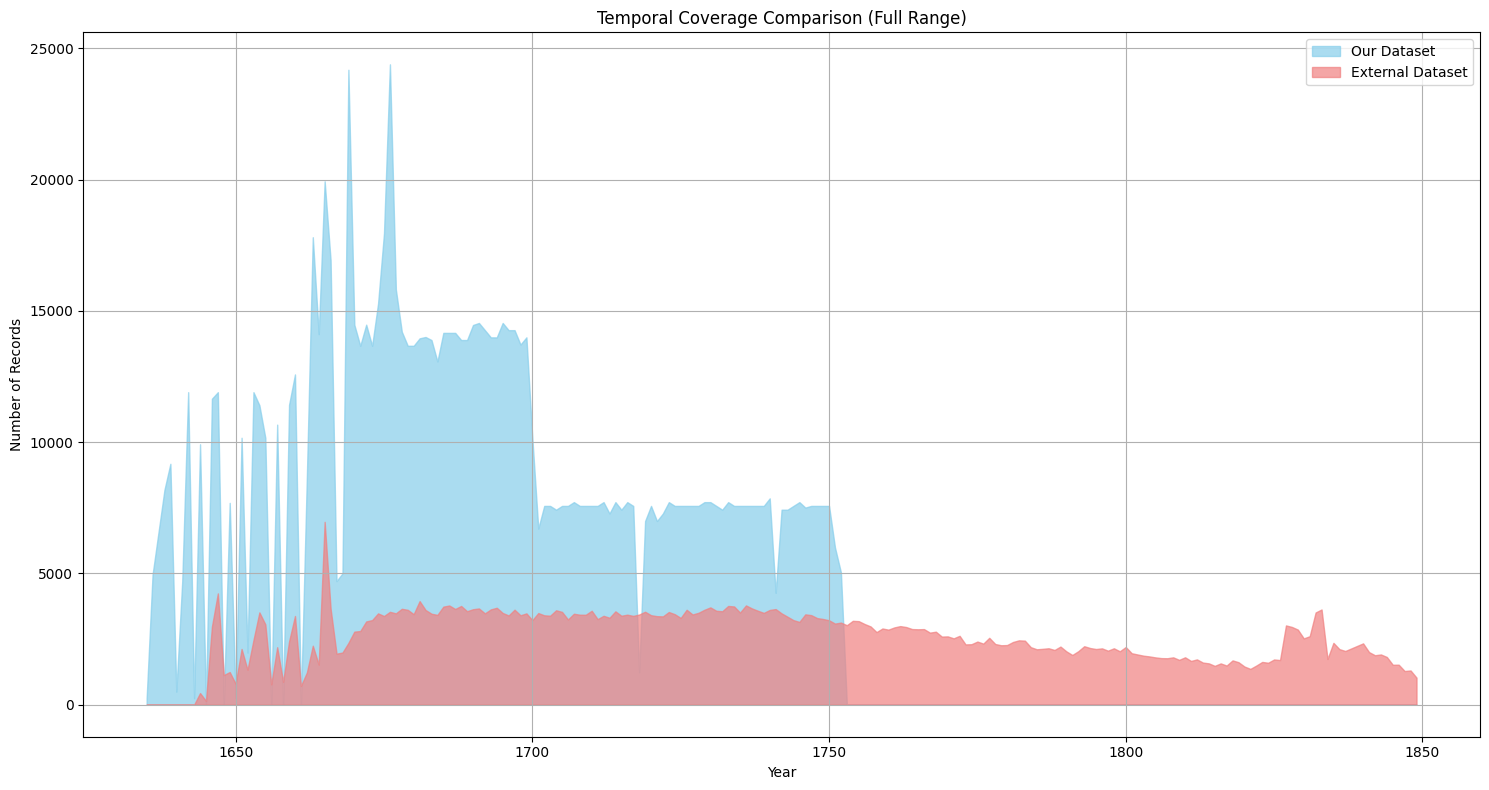

In [179]:
# Combine both datasets for full temporal coverage visualization
our_full_coverage = our_bills.groupby('year').size().reset_index(name='our_records')
ext_full_coverage = ext_transformed.groupby('year').size().reset_index(name='ext_records')

# Merge the full coverage dataframes
full_coverage_combined = pd.merge(our_full_coverage, ext_full_coverage, on='year', how='outer').fillna(0)

# Melt the dataframe for easier plotting with seaborn
full_coverage_melted = full_coverage_combined.melt(
    id_vars='year',
    value_vars=['our_records', 'ext_records'],
    var_name='dataset',
    value_name='record_count'
)

full_coverage_melted['dataset'] = full_coverage_melted['dataset'].replace({
    'our_records': 'Our Dataset',
    'ext_records': 'External Dataset'
})


# Visualize full temporal coverage as an area plot
plt.figure(figsize=(15, 8))

# Plot area for each dataset
plt.fill_between(full_coverage_combined['year'], full_coverage_combined['our_records'], color='skyblue', alpha=0.7, label='Our Dataset')
plt.fill_between(full_coverage_combined['year'], full_coverage_combined['ext_records'], color='lightcoral', alpha=0.7, label='External Dataset')


plt.title('Temporal Coverage Comparison (Full Range)')
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

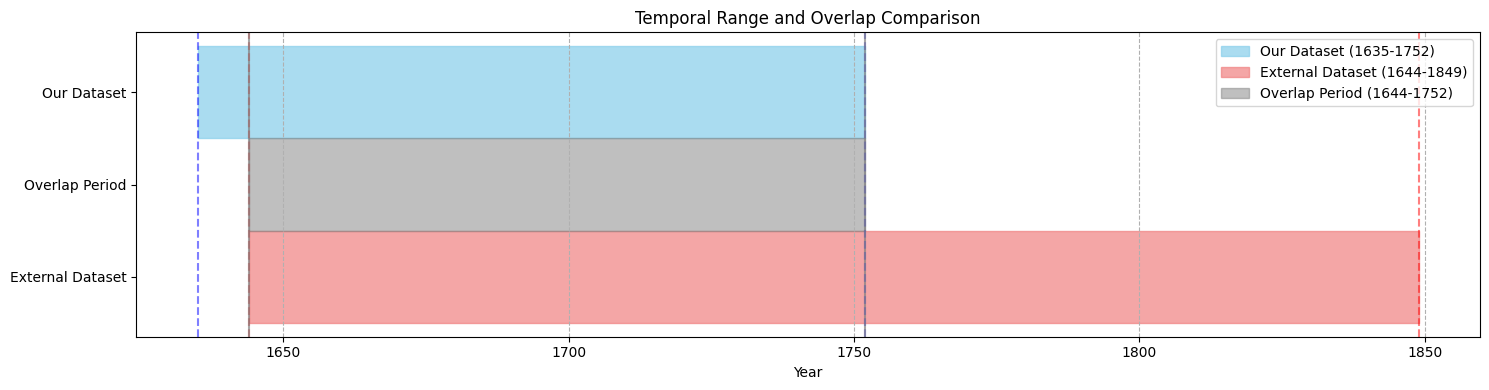

In [180]:
# Get the full year ranges for each dataset
our_min_year, our_max_year = our_bills['year'].min(), our_bills['year'].max()
ext_min_year, ext_max_year = ext_transformed['year'].min(), ext_transformed['year'].max()

# Determine the overlap period
overlap_min_year = max(our_min_year, ext_min_year)
overlap_max_year = min(our_max_year, ext_max_year)

# Create a figure and axes
fig, ax = plt.subplots(figsize=(15, 4))

# Plot our dataset's full range as an area (at y=2)
ax.fill_betweenx([2, 3], our_min_year, our_max_year, color='skyblue', alpha=0.7, label=f'Our Dataset ({our_min_year}-{our_max_year})')

# Plot external dataset's full range as an area (at y=0)
ax.fill_betweenx([0, 1], ext_min_year, ext_max_year, color='lightcoral', alpha=0.7, label=f'External Dataset ({ext_min_year}-{ext_max_year})')

# Plot the overlap period as a separate bar (at y=1)
ax.fill_betweenx([1, 2], overlap_min_year, overlap_max_year, color='grey', alpha=0.5, label=f'Overlap Period ({overlap_min_year}-{overlap_max_year})')


# Set labels and title
ax.set_xlabel('Year')
ax.set_title('Temporal Range and Overlap Comparison')
ax.set_yticks([0.5, 1.5, 2.5], ['External Dataset', 'Overlap Period', 'Our Dataset']) # Set custom y-ticks

# Add legend
ax.legend(loc='upper right')

# Add vertical lines for start and end of each dataset and overlap
ax.axvline(our_min_year, color='blue', linestyle='--', alpha=0.5)
ax.axvline(our_max_year, color='blue', linestyle='--', alpha=0.5)
ax.axvline(ext_min_year, color='red', linestyle='--', alpha=0.5)
ax.axvline(ext_max_year, color='red', linestyle='--', alpha=0.5)
ax.axvline(overlap_min_year, color='grey', linestyle='-', alpha=0.7)
ax.axvline(overlap_max_year, color='grey', linestyle='-', alpha=0.7)


plt.grid(True, axis='x', linestyle='--')
plt.tight_layout()
plt.show()

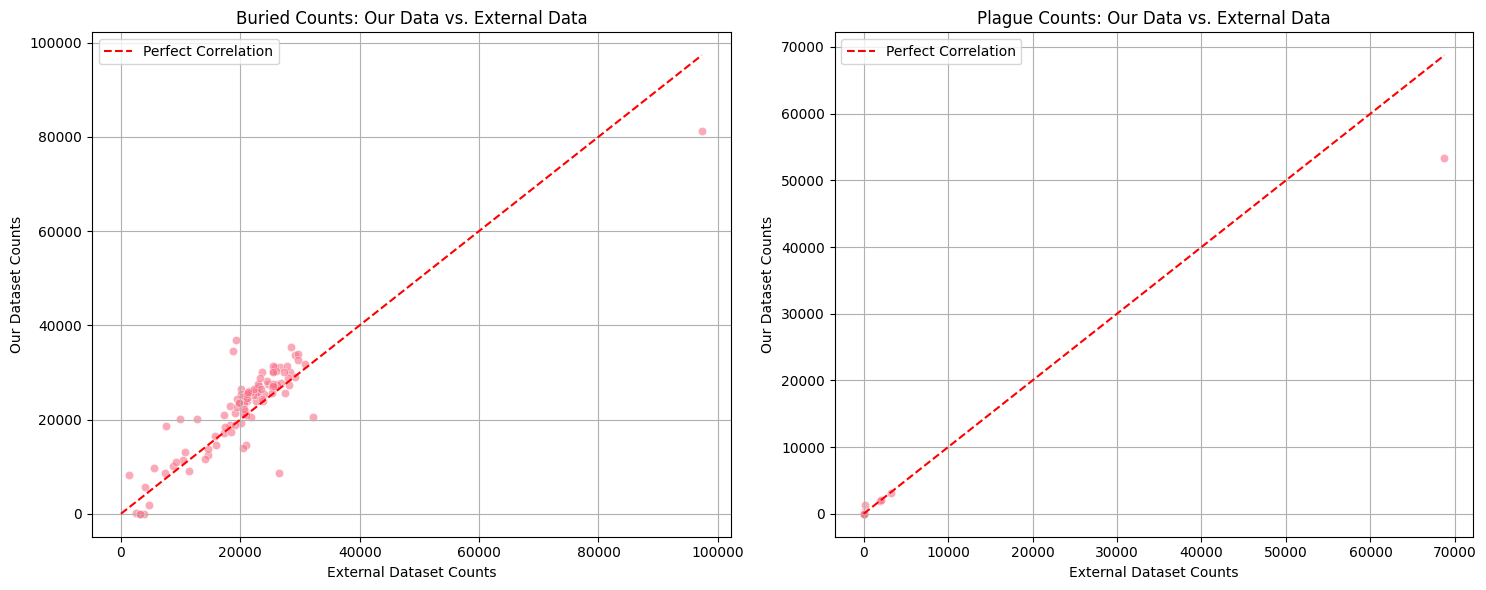

In [181]:
# Visualize correlation between our data and external data for plague and burial counts
if plague_burial_comparison is not None:
    plt.figure(figsize=(15, 6))

    # Scatter plot for Buried counts
    plt.subplot(1, 2, 1)
    buried_comparison = plague_burial_comparison[plague_burial_comparison['count_type'] == 'buried'].copy()
    sns.scatterplot(data=buried_comparison, x='external', y='ours', alpha=0.6)
    plt.title('Buried Counts: Our Data vs. External Data')
    plt.xlabel('External Dataset Counts')
    plt.ylabel('Our Dataset Counts')
    plt.grid(True)
    plt.plot([0, buried_comparison['external'].max()], [0, buried_comparison['external'].max()], color='red', linestyle='--', label='Perfect Correlation') # Add a perfect correlation line
    plt.legend()


    # Scatter plot for Plague counts
    plt.subplot(1, 2, 2)
    plague_comparison = plague_burial_comparison[plague_burial_comparison['count_type'] == 'plague'].copy()
    sns.scatterplot(data=plague_comparison, x='external', y='ours', alpha=0.6)
    plt.title('Plague Counts: Our Data vs. External Data')
    plt.xlabel('External Dataset Counts')
    plt.ylabel('Our Dataset Counts')
    plt.grid(True)
    plt.plot([0, plague_comparison['external'].max()], [0, plague_comparison['external'].max()], color='red', linestyle='--', label='Perfect Correlation') # Add a perfect correlation line
    plt.legend()


    plt.tight_layout()
    plt.show()
else:
    print("Plague and burial comparison data not available for plotting.")